In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pyfwat.pario import chpar

## Create stations

In [8]:
xmin = 0.4
xmax = 1.4
y = [-0.2, 0.0, 0.2]

net = 'MX'

with open('./DATA/STATIONS', 'w') as f:
    for j, yy in enumerate(y):
        x = np.arange(xmin, xmax+0.1, 0.1)
        for i, xx in enumerate(x):
            sta = f'ST{i+j*x.size:03d}'
            f.write(f'{sta} {net} {yy:.2f} {xx:.2f} 0.00 0.00\n')


## create initial model

In [1]:
import h5py 
with h5py.File('./target_model.h5') as f:
    x = f['x'][:]
    y = f['y'][:]
    z = f['z'][:]
    vs = f['vs'][:]
vsi = vs.copy()
vsi[:,:,0:21] = vs[0,0,0]
with h5py.File('./initial_model.h5', 'w') as f:
    f.create_dataset('x', data=x)
    f.create_dataset('y', data=y)
    f.create_dataset('z', data=z)
    f.create_dataset('vs', data=vsi)
    f.create_dataset('vp', data=vsi*1.7)
    f.create_dataset('rho', data=vsi*0.7)

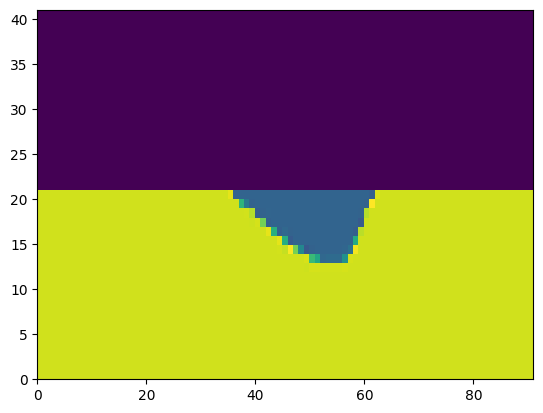

In [8]:
with h5py.File('./initial_model.h5') as f:
    vsin = f['vs'][:]

plt.pcolor(vsin[:, 20, :].T)

In [7]:
vs1, vs2 = vs[0, 0, 0], vs[0, 0, -1]
rho1, rho2 = vs1*0.7, vs2*0.7
vp1, vp2  = vs1*1.7, vs2*1.7
print("Layer1: vs, rho, vp = ", vs1, rho1, vp1)
print("Layer2: vs, rho, vp = ", vs2, rho2, vp2)

Layer1: vs, rho, vp =  4480.0 3136.0 7616.0
Layer2: vs, rho, vp =  3750.0 2625.0 6375.0


## Create sources

In [11]:
baz = np.arange(0, 360, 45)
rayp = 0.06
inc_angle = np.rad2deg(np.arcsin(0.06*vp1/1000))
with open('./DATA/FKMODEL') as f:
    fkstr =  f.read()
fkstr = chpar(fkstr, 'TAKE_OFF', inc_angle, 'fk')
for i, b in enumerate(baz):
    fkb = chpar(fkstr, 'BACK_AZIMUTH', b, 'fk')
    with open(f'./src_rec/FKMODEL_{i}', 'w') as f:
        f.write(fkb)
    os.system(f'cp ./DATA/STATIONS ./src_rec/STATIONS_{i}')


## Create sources list

In [12]:
with open('./src_rec/sources_set0.dat', 'w') as f:
    for i, b in enumerate(baz):
        f.write(f'{i} 0.0 0.0 0.0 0.0 1.0\n')